In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add Code folder
import sys
sys.path.append('../qdarts')

# import main class and plotting function
from experiment import Experiment
from plotting import plot_polytopes

# import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



## Device definition

In [92]:
# Define the system

#All capacitances are given in aF
N = 3 #number of dots   
C_DD=20* np.eye((N))/2 #The self-capacitance of each dot, NOTE: factor of 2 due to symmetrization
C_DD[0,1] = 10 #capacitance between dot 0 and dot 1 (Left double dot) 
C_DD[1,2] = 5 #capacitance between dot 1 and dot 2 (Right double dot)
C_DD[0,2] = 1 #capacitance between dot 0 and dot 2

C_DD = C_DD + C_DD.T

C_DG=11*np.eye(N) #dot-to-gate capacitances 
#cross-capacitances
C_DG[0,1] = 1.5 #dot 0 from dot 1
C_DG[1,0] = 1.2 #dot 1 from dot 0

# Definition of the tunnel couplings in eV 
# NOTE: we use the convention that tc is the energy gap at avoided crossing H = tc/2 sx
tunnel_couplings = np.zeros((N,N))
tunnel_couplings[0,1] = 100*1e-6


In [93]:
capacitance_config = {
        "C_DD" : C_DD,  #dot-dot capacitance matrix
        "C_Dg" : C_DG,  #dot-gate capacitance matrix
        "ks" : 4,       #distortion of Coulomb peaks. NOTE: If None -> constant size of Coublomb peak 
}

tunneling_config = {
        "tunnel_couplings": tunnel_couplings, #tunnel coupling matrix
        "temperature": 0.1,                   #temperature in Kelvin
        "energy_range_factor": 5,  #energy scale for the Hamiltonian generation. NOTE: Smaller -> faster but less accurate computation 
}
sensor_config = {
        "sensor_dot_indices": [2],  #Indices of the sensor dots
        "sensor_detunings": [-0.0005],  #Detuning of the sensor dots
        "noise_amplitude": {"fast_noise": 0.8*1e-4, "slow_noise": 1e-6}, #Noise amplitude for the sensor dots in eV
        "peak_width_multiplier": 15,  #Width of the sensor peaks in the units of thermal broadening m *kB*T/0.61.
}


In [94]:
# Create the experiment object from the configuration files
experiment = Experiment(capacitance_config, tunneling_config, sensor_config)

EXPERIMENT INITIALIZED
-----------------------

                Capacitance model deployed with the following parameters:
                Dot-dot capacitances: 
                [[20. 10.  1.]
 [10. 20.  5.]
 [ 1.  5. 20.]]
                Dot-gate capacitances: 
                [[11.   1.5  0. ]
 [ 1.2 11.   0. ]
 [ 0.   0.  11. ]]
                Size of Coulomb peaks V[n] is constant
                

            Sensor model deployed with the following parameters:   
            Sensor dot indices: [2]
            Sensor detunings: [-0.5] meV
            Coulomb peak width: 0.41 meV
            Slow noise amplitude: 1.0 ueV
            Fast noise amplitude: 80.0 ueV
            

            Tunneling model deployed with the following parameters:
            Tunneling matrix:
            [[0.e+00 1.e-04 0.e+00]
 [0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00]]
            Temperature: 0.1 K
            Energy range factor: 5
            


In [95]:
xexp, yexp, _, polytopesexp, sensor_signalexp, _ = experiment.generate_CSD(
                                    plane_axes = np.array([[1,0,0],[0,1,0]]), # vectors spanning the cut in voltage space
                                    target_state = [1,0,5],  # target state for transition
                                    target_transition = [-1,1,0], #target transition from target state, here transition to [2,3,2,3,5,5]
                                    x_voltages=np.linspace(-0.005, 0.005, 100), #voltage range for x-axis
                                    y_voltages=np.linspace(-0.005, 0.005, 100), #voltage range for y-axis
                                    compute_polytopes = True, #compute the corners of constant occupation
                                    compensate_sensors=True, #compensate the sensor signals
                                    use_virtual_gates=True, #use the virtual gates
                                    use_sensor_signal=True) #use the sensor signals

v_offset found: [0.0065 0.0071]


In [96]:
# Control plot

def plot_CSD(xexp, yexp, sensor_signalexp, polytopesexp, x0,x1):
    fig, ax = plt.subplots(1,1)
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    #Conductance of the dot 4 (Left sensor dot)
    ax.set_title("Sensor 4", fontsize=14)
    ax.pcolormesh(1e3*xexp,1e3*yexp,sensor_signalexp[:,:,0])
    plot_polytopes(ax,polytopesexp, axes_rescale=1e3)  # plot the polytopes to see the constant occupation regions
    ax.set_xlim(xexp[0]*1e3,xexp[-1]*1e3)
    ax.set_ylim(yexp[0]*1e3,yexp[-1]*1e3) 
    plt.plot(x0*1e3,x1*1e3, 'k-', linewidth=2)
    #plt.quiver((x0[0]+x1[0])/2*1e3,(x0[1]+x1[1])/2*1e3, np.diff(x0), np.diff(x1), angles='xy', scale_units='xy', scale=1, color='black')

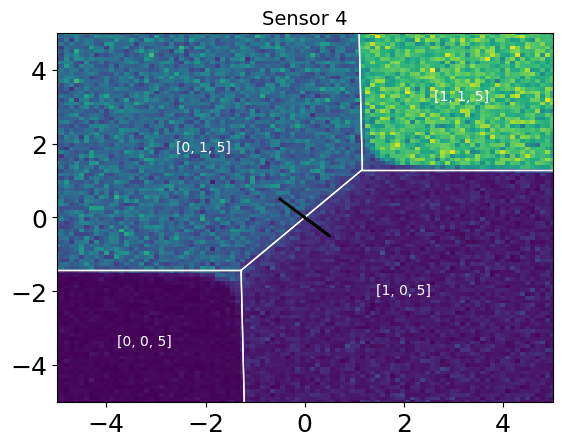

In [97]:
## Let's do latching
Initial_position = np.array([-0.0005,0.0005,0])
Final_position = np.array([0.0005,-0.0005,0])
plot_CSD(xexp, yexp, sensor_signalexp, polytopesexp, np.array(Initial_position), np.array(Final_position))


[-0.0005  0.0005  0.    ]
[-0.0004  0.0004  0.    ]
[-0.0003  0.0003  0.    ]
[-0.0002  0.0002  0.    ]
[-1.e-04  1.e-04  0.e+00]
[0. 0. 0.]
[ 0.0001 -0.0001  0.    ]
[ 0.0002 -0.0002  0.    ]
[ 0.0003 -0.0003  0.    ]
[ 0.0004 -0.0004  0.    ]
[ 0.0005 -0.0005  0.    ]
[ 0.0006 -0.0006  0.    ]
[ 0.0007 -0.0007  0.    ]
[ 0.0008 -0.0008  0.    ]
[ 0.0009 -0.0009  0.    ]
[ 0.001 -0.001  0.   ]
[ 0.0011 -0.0011  0.    ]
[ 0.0012 -0.0012  0.    ]
[ 0.0013 -0.0013  0.    ]
[ 0.0014 -0.0014  0.    ]
[ 0.0015 -0.0015  0.    ]
[ 0.0016 -0.0016  0.    ]
[ 0.0017 -0.0017  0.    ]
[ 0.0018 -0.0018  0.    ]
[ 0.0019 -0.0019  0.    ]
[ 0.002 -0.002  0.   ]
[ 0.0021 -0.0021  0.    ]
[ 0.0022 -0.0022  0.    ]
[ 0.0023 -0.0023  0.    ]
[ 0.0024 -0.0024  0.    ]
[ 0.0025 -0.0025  0.    ]
[ 0.0026 -0.0026  0.    ]
[ 0.0027 -0.0027  0.    ]
[ 0.0028 -0.0028  0.    ]
[ 0.0029 -0.0029  0.    ]
[ 0.003 -0.003  0.   ]
[ 0.0031 -0.0031  0.    ]
[ 0.0032 -0.0032  0.    ]
[ 0.0033 -0.0033  0.    ]
[ 0.0034 -

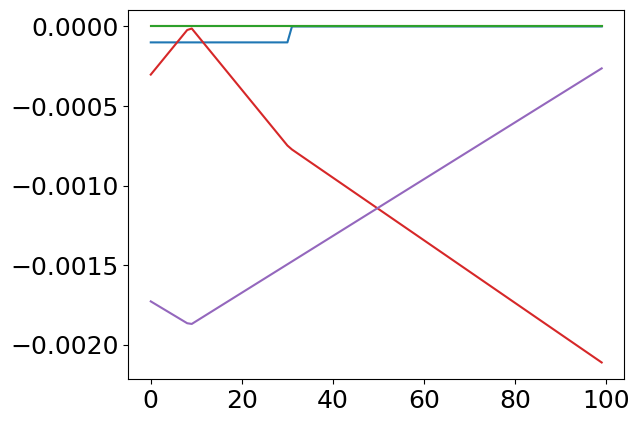

In [103]:
steps = 100
depses = (Final_position - Initial_position)/10
eps01 = []
eps12 = []
tcs01 = []
tcs02 = []
tcs12 = []
for k in range(steps):
    H = experiment.tunneling_sim.get_Hamiltonian(Initial_position+k*depses, [0,1,5])
    print(Initial_position+k*depses)
    inds = np.argsort(np.diag(H))[:3]
    Heff = np.zeros((3,3))
    for n,ind in enumerate(inds):
        for m, ind2 in enumerate(inds):
            Heff[n,m] = H[ind,ind2]

    tcs12.append(Heff[1,2])
    tcs02.append(Heff[0,2])
    tcs01.append(Heff[0,1])
    eps12.append(Heff[1,1]-Heff[2,2])
    eps01.append(Heff[0,0]-Heff[1,1])
    #plt.figure()
    #plt.imshow(Heff)

    # 
plt.plot(tcs12, label='tc12')
plt.plot(tcs02, label='tc02')
plt.plot(tcs01, label = 'tc01')   
plt.plot(eps12, label='eps12')
plt.plot(eps01, label='eps01')  

   
    


In [58]:
tcs

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

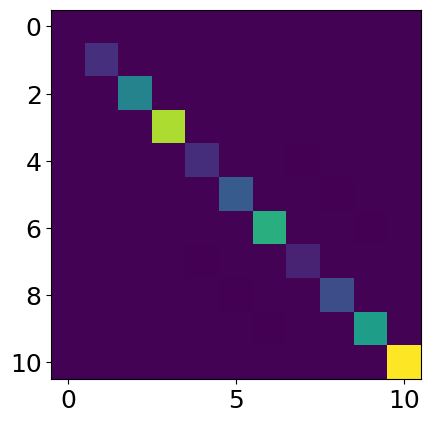

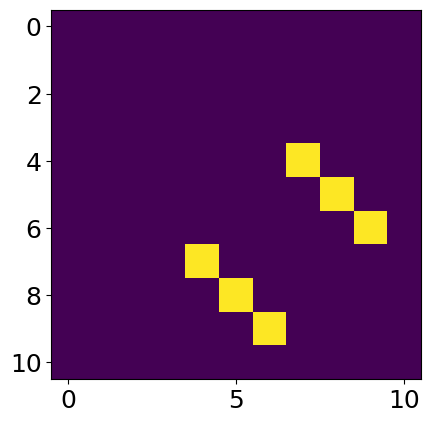

In [53]:
# print H matrix using 2 significant digits
np.set_printoptions(precision=4)
#plot the Hamiltonian
plt.figure()
plt.imshow(H)

#plot off-diagonal elements
plt.figure()
plt.imshow(np.abs(H-np.diag(np.diag(H))))

